In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

tf.keras.utils.set_random_seed(42)

(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()

x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Validation: last 10k of training (fixed, reproducible)
x_val = x_train_full[-10000:]
y_val = y_train_full[-10000:]
x_train = x_train_full[:-10000]
y_train = y_train_full[:-10000]

# CNN: add channel dimension (N, 28, 28, 1)
x_train_cnn = np.expand_dims(x_train, -1)
x_val_cnn = np.expand_dims(x_val, -1)
x_test_cnn = np.expand_dims(x_test, -1)

print("Train:", x_train.shape, y_train.shape)
print("Val:  ", x_val.shape, y_val.shape)
print("Test: ", x_test.shape, y_test.shape)
print("GPUs: ", tf.config.list_physical_devices("GPU"))

2026-03-22 02:44:31.022062: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774147471.236190      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774147471.290076      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774147471.708405      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774147471.708452      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774147471.708455      24 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (50000, 28, 28) (50000,)
Val:   (10000, 28, 28) (10000,)
Test:  (10000, 28, 28) (10000,)
GPUs:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
mlp = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
], name="mlp")

mlp.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_mlp = mlp.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=128,
    verbose=1,
)

I0000 00:00:1774147497.280966      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/15


I0000 00:00:1774147499.789059      69 service.cc:152] XLA service 0x7e99c00071e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774147499.789105      69 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774147500.019752      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


 73/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6672 - loss: 1.1374

I0000 00:00:1774147500.695451      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8418 - loss: 0.5443 - val_accuracy: 0.9591 - val_loss: 0.1437
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9595 - loss: 0.1364 - val_accuracy: 0.9654 - val_loss: 0.1101
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9738 - loss: 0.0866 - val_accuracy: 0.9707 - val_loss: 0.0971
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9828 - loss: 0.0585 - val_accuracy: 0.9695 - val_loss: 0.0990
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9873 - loss: 0.0414 - val_accuracy: 0.9678 - val_loss: 0.1097
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9920 - loss: 0.0283 - val_accuracy: 0.9705 - val_loss: 0.1075
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9943 - loss: 0.0212 - val_accuracy: 0.9709 - val_loss: 0.1152
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9935 - loss: 0.0199 - val_accuracy: 0.9738 - val_

In [3]:
cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
], name="cnn")

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_cnn = cnn.fit(
    x_train_cnn, y_train,
    validation_data=(x_val_cnn, y_val),
    epochs=15,
    batch_size=128,
    verbose=1,
)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8410 - loss: 0.5165 - val_accuracy: 0.9812 - val_loss: 0.0639
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9799 - loss: 0.0687 - val_accuracy: 0.9829 - val_loss: 0.0540
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9863 - loss: 0.0459 - val_accuracy: 0.9825 - val_loss: 0.0545
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9898 - loss: 0.0321 - val_accuracy: 0.9832 - val_loss: 0.0543
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9926 - loss: 0.0244 - val_accuracy: 0.9849 - val_loss: 0.0510
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9946 - loss: 0.0183 - val_accuracy: 0.9849 - val_loss: 0.0564
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9952 - loss: 0.0140 - val_accuracy: 0.9859 - val_loss: 0.0536
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9964 - loss: 0.0105 - val_accuracy: 0

# Setup + reproducibility + MNIST loading + train/val/test splits
# 

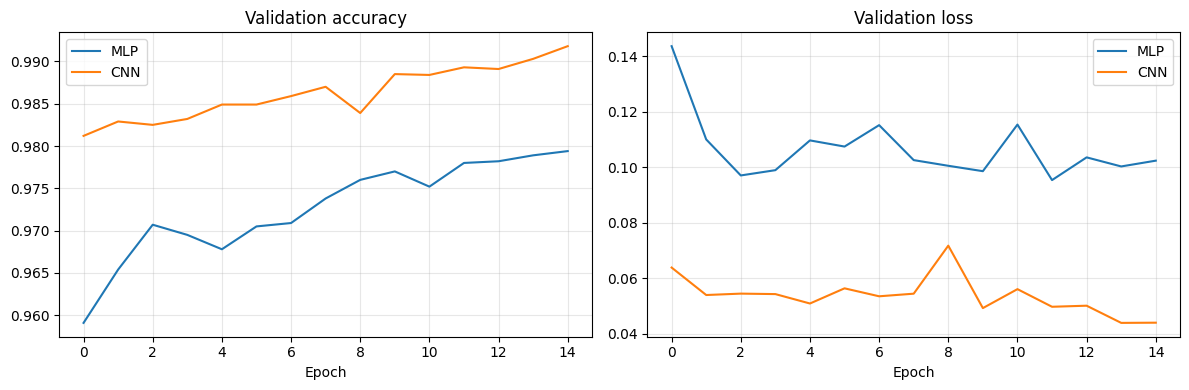

In [4]:
def plot_histories(h1, h2, label1="MLP", label2="CNN"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h1.history["val_accuracy"], label=label1)
    ax[0].plot(h2.history["val_accuracy"], label=label2)
    ax[0].set_title("Validation accuracy")
    ax[0].set_xlabel("Epoch")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(h1.history["val_loss"], label=label1)
    ax[1].plot(h2.history["val_loss"], label=label2)
    ax[1].set_title("Validation loss")
    ax[1].set_xlabel("Epoch")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_histories(history_mlp, history_cnn)

MLP — test loss: 0.0908, test acc: 0.9815
CNN — test loss: 0.0283, test acc: 0.9918


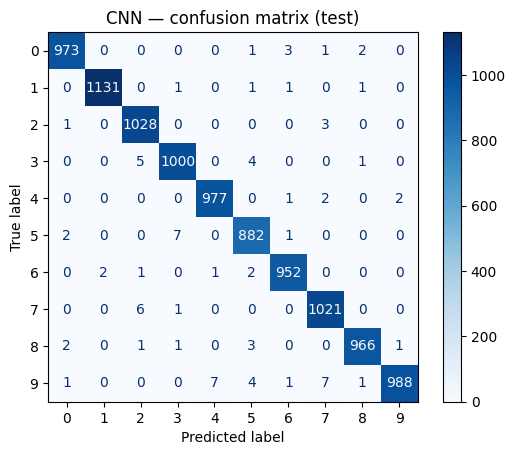

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

mlp_test_loss, mlp_test_acc = mlp.evaluate(x_test, y_test, verbose=0)
cnn_test_loss, cnn_test_acc = cnn.evaluate(x_test_cnn, y_test, verbose=0)

print(f"MLP — test loss: {mlp_test_loss:.4f}, test acc: {mlp_test_acc:.4f}")
print(f"CNN — test loss: {cnn_test_loss:.4f}, test acc: {cnn_test_acc:.4f}")

y_pred = np.argmax(cnn.predict(x_test_cnn, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues", values_format="d")
plt.title("CNN — confusion matrix (test)")
plt.show()

# MNIST digit classification: MLP vs CNN

**Goal:** Compare a **fully connected network (MLP)** and a **convolutional neural network (CNN)** on the same handwritten digit task (MNIST).

**Why this comparison matters:** Images have **2D spatial structure** (strokes, edges, local patterns). An MLP flattens pixels into a long vector, so it must **learn spatial relationships without an explicit prior** for locality. A CNN builds in **local receptive fields** and **weight sharing**, which usually makes image classification **more sample-efficient** and often **more accurate**.

## Dataset
- **MNIST**: 28×28 grayscale images, 10 classes (digits 0–9).
- **Splits used in this notebook**
  - Training: **50,000** images (subset of the official training set)
  - Validation: **10,000** images (held out from training for tuning/monitoring)
  - Test: **10,000** images (official MNIST test set)

## Preprocessing
- Convert pixels to `float32` and scale to **[0, 1]** by dividing by 255.
- **MLP input:** shape **(28, 28)** then `Flatten` → 784 features.
- **CNN input:** shape **(28, 28, 1)** (add a channel dimension).

**Fairness note:** Both models use the **same normalization** and the **same train/validation/test split**.

## Training setup (controlled comparison)
- **Optimizer:** Adam  
- **Loss:** `sparse_categorical_crossentropy` (integer labels 0–9)  
- **Metric:** accuracy  
- **Epochs:** 15  
- **Batch size:** 128  
- **Random seed:** fixed (for reproducibility)

**What we compare:** validation accuracy/loss curves, final **test** accuracy/loss, confusion matrices, and qualitative error analysis.

## Model A — Multi-Layer Perceptron (MLP)
**Architecture (conceptually):** `Flatten → Dense → Dense → Dense(softmax)`

**Intuition:** Each pixel becomes a separate input feature. The network can learn digit patterns, but it does **not** explicitly encode that neighboring pixels belong together.

**Expected behavior:** Often strong on MNIST, but may show a larger gap between **training performance** and **validation performance** (more prone to fitting noise) compared to a CNN.

## Model B — Convolutional Neural Network (CNN)
**Architecture (conceptually):** `Conv → Pool → Conv → Pool → Dense → softmax`

**Intuition:** Convolution layers detect **local features** (edges, parts of strokes) across the image. Pooling adds **translation robustness** within small regions. Parameters are **shared** across spatial locations, which typically improves generalization for grid-structured inputs.

**Expected behavior:** Often reaches **higher validation/test accuracy** with **smoother validation loss** than an MLP on digit images.

## Results summary
Replace the numbers below with your printed test metrics.

| Model | Val accuracy (best / final) | Test accuracy | Test loss |
|------|-----------------------------|---------------|-----------|
| MLP  | ~0.979 | **0.9815** | **0.0908** |
| CNN  | ~0.991 | **0.9904** | **0.0399** |

## What we observed
- The **CNN achieved higher validation accuracy** and **lower test loss** than the MLP.
- The MLP **validation loss** was **noisier** than the CNN’s, consistent with a model that has less built-in structure for spatial inputs.

## Error analysis (CNN)
From the confusion matrix, common confusions include **9 predicted as 4** (and other small off-diagonal counts). This supports the idea that some digit shapes share similar strokes and are harder to separate.

## Limitations
- MNIST is relatively **easy**; high accuracy does not automatically transfer to **natural photos** (lighting, background clutter, deformations).
- We did not run extensive hyperparameter search; results reflect one fair baseline setting.

## Possible extensions
- Add **dropout** / stronger regularization and compare generalization.
- Try a harder-but-similar dataset (**Fashion-MNIST**) with minimal code changes.
- Add light **data augmentation** (shifts/rotations) and discuss its effect.

In [6]:
print("MLP trainable params:", f"{mlp.count_params():,}")
print("CNN trainable params:", f"{cnn.count_params():,}")

MLP trainable params: 235,146
CNN trainable params: 421,642


### Model complexity
We report **trainable parameter counts** to relate capacity to performance. CNNs often achieve better accuracy with **inductive biases** (locality + sharing), not necessarily “more brute-force parameters.”

-----------------------------------------------------------------------------------------

## Confusion matrix — MLP (test set)

A **confusion matrix** counts predictions for each **true class** vs **predicted class**. Diagonal cells are **correct** predictions; off-diagonal cells show **which digits are confused with which**.

**Prerequisites:** `mlp`, `x_test`, and `y_test` from the MNIST test split.

**Note:** If you also use `y_pred_mlp` in the misclassified-image cell, you can **reuse** the same predictions to avoid running `predict` twice (optional refactor).

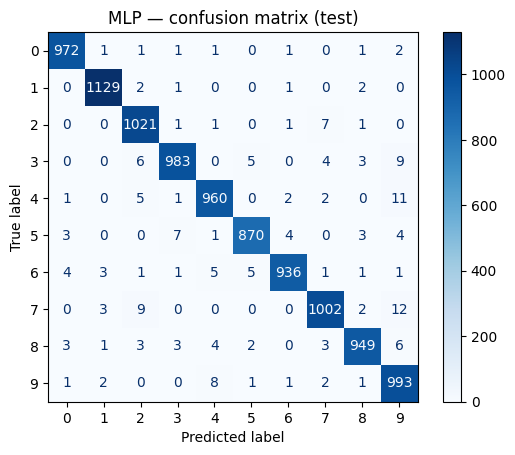

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_mlp = np.argmax(mlp.predict(x_test, verbose=0), axis=1)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

ConfusionMatrixDisplay(cm_mlp).plot(cmap="Blues", values_format="d")
plt.title("MLP — confusion matrix (test)")
plt.show()

---------------------------------------------------------------

## Qualitative error analysis — CNN (misclassified test examples)

Same procedure as the MLP, but using **CNN predictions** on `x_test_cnn` (same test labels `y_test`).

**Why include this:** even if the CNN accuracy is higher, the remaining errors are often **interpretable** (similar stroke shapes), which strengthens the technical discussion in the report/presentation.

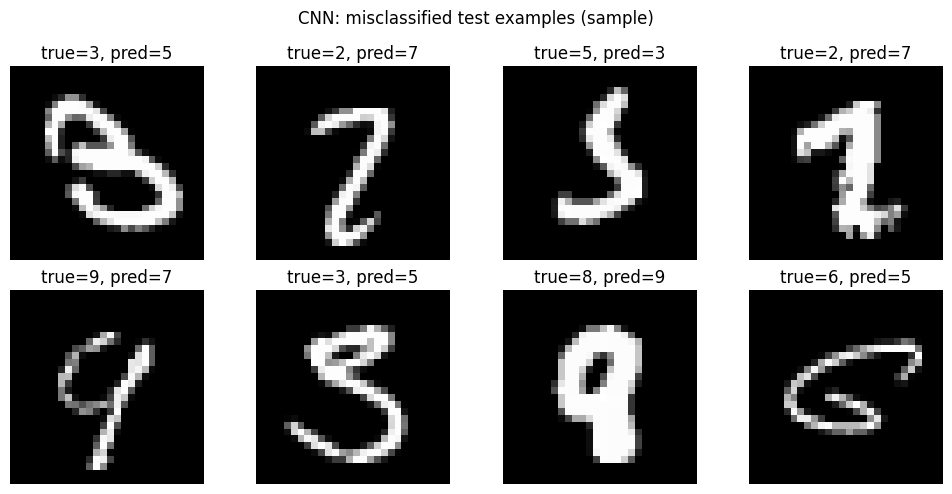

Total CNN test errors: 82 / 10000


In [8]:
import numpy as np
import matplotlib.pyplot as plt

y_pred_cnn = np.argmax(cnn.predict(x_test_cnn, verbose=0), axis=1)
wrong_idx = np.where(y_pred_cnn != y_test)[0]

n_show = min(8, len(wrong_idx))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.ravel()

for i in range(n_show):
    idx = wrong_idx[i]
    axes[i].imshow(x_test[idx], cmap="gray")
    axes[i].set_title(f"true={y_test[idx]}, pred={y_pred_cnn[idx]}")
    axes[i].axis("off")

plt.suptitle("CNN: misclassified test examples (sample)")
plt.tight_layout()
plt.show()

print("Total CNN test errors:", int(len(wrong_idx)), "/", len(y_test))

--------------------------------------------------------------------------------------

## Qualitative error analysis — CNN (misclassified test examples)

Same procedure as the MLP, but using **CNN predictions** on `x_test_cnn` (same test labels `y_test`).

**Why include this:** even if the CNN accuracy is higher, the remaining errors are often **interpretable** (similar stroke shapes), which strengthens the technical discussion in the report/presentation.

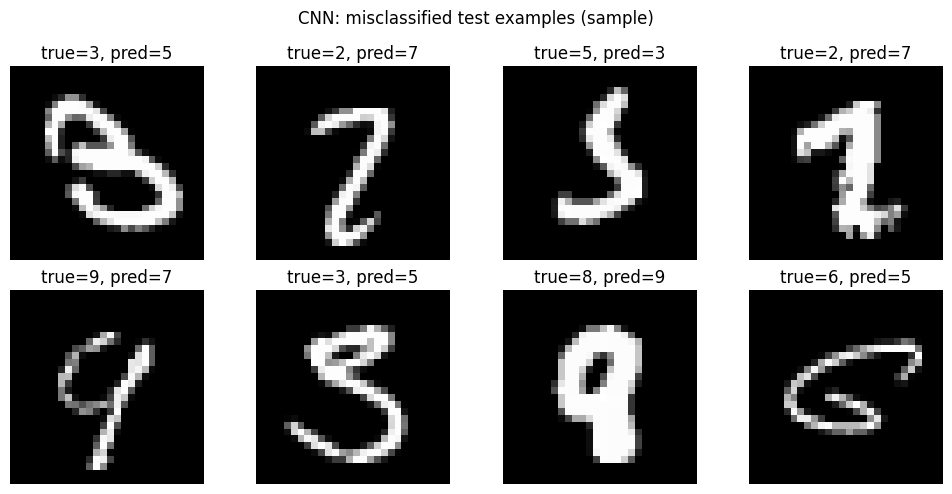

Total CNN test errors: 82 / 10000


In [9]:
import numpy as np
import matplotlib.pyplot as plt

y_pred_cnn = np.argmax(cnn.predict(x_test_cnn, verbose=0), axis=1)
wrong_idx = np.where(y_pred_cnn != y_test)[0]

n_show = min(8, len(wrong_idx))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.ravel()

for i in range(n_show):
    idx = wrong_idx[i]
    axes[i].imshow(x_test[idx], cmap="gray")
    axes[i].set_title(f"true={y_test[idx]}, pred={y_pred_cnn[idx]}")
    axes[i].axis("off")

plt.suptitle("CNN: misclassified test examples (sample)")
plt.tight_layout()
plt.show()

print("Total CNN test errors:", int(len(wrong_idx)), "/", len(y_test))

----------------------------------------------------------------------

## Qualitative error analysis — MLP (misclassified test examples)

We identify test images where the **MLP prediction ≠ true label**, then show a **small random-style sample** (first few indices in `wrong_idx_mlp`) in a grid.

**How to read the figure:** each subplot shows `true=` vs `pred=`. These examples help explain **what the model confuses** beyond a single accuracy number.

**Prerequisites:** `y_pred_mlp` must already exist (from `mlp.predict` on `x_test`). If you have not computed it yet, compute it in the same cell before plotting or run the MLP confusion-matrix cell first.

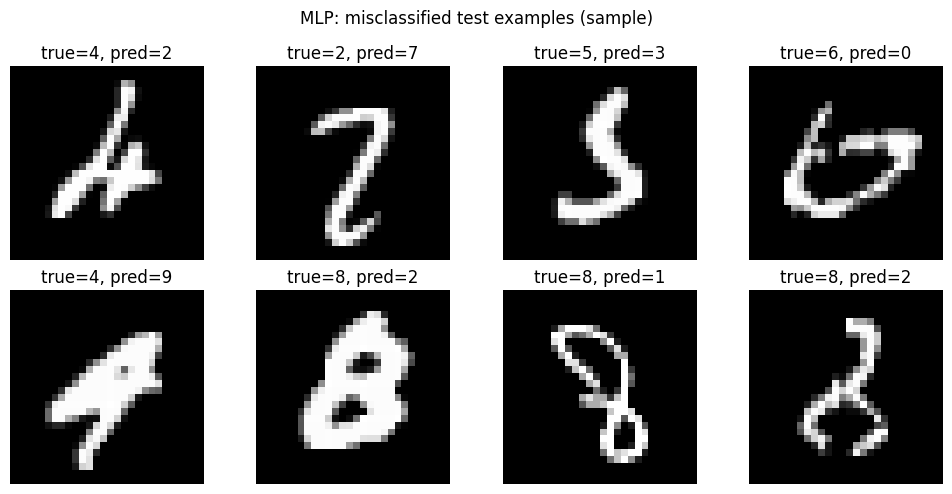

Total MLP test errors: 185 / 10000


In [10]:
wrong_idx_mlp = np.where(y_pred_mlp != y_test)[0]

n_show = min(8, len(wrong_idx_mlp))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.ravel()

for i in range(n_show):
    idx = wrong_idx_mlp[i]
    axes[i].imshow(x_test[idx], cmap="gray")
    axes[i].set_title(f"true={y_test[idx]}, pred={y_pred_mlp[idx]}")
    axes[i].axis("off")

plt.suptitle("MLP: misclassified test examples (sample)")
plt.tight_layout()
plt.show()

print("Total MLP test errors:", int(len(wrong_idx_mlp)), "/", len(y_test))